# Notebook Instructions

1. If you are new to Jupyter notebooks, please go through this introductory manual <a href='https://quantra.quantinsti.com/quantra-notebook' target="_blank">here</a>.
1. Any changes made in this notebook would be lost after you close the browser window. **You can download the notebook to save your work on your PC.**
1. Before running this notebook on your local PC:<br>
i.  You need to set up a Python environment and the relevant packages on your local PC. To do so, go through the section on "**Run Codes Locally on Your Machine**" in the course.<br>
ii. You need to **download the zip file available in the last unit** of this course. The zip file contains the data files and/or python modules that might be required to run this notebook.

# Trend Based Strategy Using Weekly Woodie's

In the previous units, you learnt about yet another strategy using the weekly Woodie's pivots, which is designed specifically to capture trend-based or breakout opportunities. In this notebook, you will learn to code and implement the same strategy in a detailed manner using Python.

This notebook is structured as follows:
1. [Import Libraries](#libraries)
2. [Import the Data](#data)
3. [Resample the Data](#resample)
4. [Calculate the Woodie's Pivot Points](#pivots)
5. [Merge the Data](#merge)
6. [Generate the Trading Signals](#signals)
7. [Backtest the Strategy](#strategy)
8. [Trade Level Analytics](#trade-level-analytics)
9. [Strategy Performance](#performance)
10. [Summary and Next Steps](#summary)

Note: The code under steps 1, 2, 3 and 4 remains the same as seen in the previous notebook on 'Range Trading Strategy using Weekly Pivots'. You can go through the same for a quick revision. Alternatively, you may choose to proceed to the step [Generate the Trading Signals](#signals).

<a id='libraries'></a>
## Import Libraries

In [1]:
# For data manipulation
import pandas as pd
import numpy as np

# Ignore warnings
import warnings 
warnings.filterwarnings('ignore')

# For datetime manipulation
from datetime import timedelta

# Import utility functions 
import sys
sys.path.append('..')
from data_modules.price_action_util_quantra import backtester, trade_level_analytics, get_performance_metrics

<a id='data'></a>
## Import the Data

From the `data_modules` folder, let's import the minute-wise price data of the Apple stock which is stored in a CSV file named `apple_1_minute_2015_2021.csv`. This CSV file is available in the zip file of the unit 'Python Codes and Data' in the 'Course Summary' section.

We will use the `read_csv` method of `pandas` to import the data and then store it in a dataframe named `data`.

In [2]:
# Import the stock price data
data = pd.read_csv('../data_modules/apple_1_minute_2015_2021.csv', index_col=0)

# Change the index type to datetime
data.index = pd.to_datetime(data.index)

# Print first 5 rows of the data
data.head()

,Open,High,Low,Close
2015-01-02 09:30:00+00:00,27.8475,27.8600,27.800,27.810
2015-01-02 09:31:00+00:00,27.8100,27.8475,27.785,27.825
2015-01-02 09:32:00+00:00,27.8250,27.8475,27.815,27.825
2015-01-02 09:33:00+00:00,27.8225,27.8250,27.780,27.795
2015-01-02 09:34:00+00:00,27.7950,27.8100,27.760,27.760


<a id='resample'></a>
## Resample the Data

For the trend based trading strategy using Woodie's Pivots, we would need the resampled data in weekly, daily and 15-min frequencies. 

The weekly resampled data will be used for calculating the Woodie's pivots, since the Woodie's pivots work well on longer timeframes. 

The daily and the 15-min resampled data on the other hand, would be used for checking strategy related conditions and for determining the entry and exit signals. For now, we can proceed with resampling the minute level data.

In [3]:
# Aggregate function
ohlcv_dict = {'Open': 'first',
              'High': 'max',
              'Low': 'min',
              'Close': 'last'
             }

# Fetch the weekly resampled data
data_weekly = data.resample('W-FRI', label='right', closed='right').agg(ohlcv_dict).dropna()
data_weekly.index += timedelta(hours=16, minutes=0)

# Fetch the daily resampled data
data_daily = data.resample('1d', label='left', closed='right').agg(ohlcv_dict).dropna()
data_daily.index += timedelta(hours=9, minutes=30)

# Fetch and display the 15-min resampled data
data_15 = data.resample('15min', label='right', closed='right').agg(ohlcv_dict).dropna()
data_15.head()

,Open,High,Low,Close
2015-01-02 09:30:00+00:00,27.8475,27.8600,27.8000,27.8100
2015-01-02 09:45:00+00:00,27.8100,27.8525,27.6375,27.6475
2015-01-02 10:00:00+00:00,27.6500,27.6625,27.1625,27.3750
2015-01-02 10:15:00+00:00,27.3750,27.4800,27.3000,27.3175
2015-01-02 10:30:00+00:00,27.3175,27.3375,27.1925,27.2800


In [4]:
# Display the daily data
data_daily.head()

,Open,High,Low,Close
2015-01-02 09:30:00+00:00,27.8475,27.8600,26.8375,27.3250
2015-01-05 09:30:00+00:00,27.0725,27.1625,26.3525,26.5625
2015-01-06 09:30:00+00:00,26.6700,26.8575,26.1575,26.5575
2015-01-07 09:30:00+00:00,26.7950,27.0500,26.6750,26.9375
2015-01-08 09:30:00+00:00,27.3075,28.0375,27.1750,27.9675


In [5]:
# Display the weekly data
data_weekly.head()

,Open,High,Low,Close
2015-01-02 16:00:00+00:00,27.8475,27.8600,26.8375,27.3250
2015-01-09 16:00:00+00:00,27.0725,28.3125,26.1575,28.0000
2015-01-16 16:00:00+00:00,28.1575,28.2000,26.3000,26.4950
2015-01-23 16:00:00+00:00,26.9650,28.4375,26.6250,28.2475
2015-01-30 16:00:00+00:00,28.4075,30.0000,27.2575,29.2900


<a id='pivots'></a>
## Calculate Woodies Pivot Points

The following code for computing Woodie's pivots is the same as we have already learned in the previous notebook. 
Note that we will compute the Woodie's pivots based on the weekly frequency.

In [6]:
# Initialise the previous high, low, close
prev_high = data_weekly['High'].shift(1)
prev_low = data_weekly['Low'].shift(1)
prev_close = data_weekly['Close'].shift(1)

# Calculate the Woodie's pivot level
data_weekly['W-Pivot'] = (prev_high + prev_low + (2*prev_close))/4

# Calculate the Woodie's resistance levels
data_weekly['R1'] = 2*data_weekly['W-Pivot'] - prev_low
data_weekly['R2'] = data_weekly['W-Pivot'] + (prev_high - prev_low)
data_weekly['R3'] = prev_high + 2*(data_weekly['W-Pivot'] - prev_low)

# Calculate the Woodie's support levels
data_weekly['S1'] = 2 * data_weekly['W-Pivot'] - prev_high
data_weekly['S2'] = data_weekly['W-Pivot'] - (prev_high - prev_low)
data_weekly['S3'] = prev_low - 2*(prev_high - data_weekly['W-Pivot'])

# Drop all NaN values from the dataframe
data_weekly.dropna(axis=0, how='any', inplace=True)

# Display the data
data_weekly.head()

,Open,High,Low,Close,W-Pivot,R1,R2,R3,S1,S2,S3
2015-01-09 16:00:00+00:00,27.0725,28.3125,26.1575,28.0000,27.336875,27.83625,28.359375,28.85875,26.81375,26.314375,25.79125
2015-01-16 16:00:00+00:00,28.1575,28.2000,26.3000,26.4950,27.617500,29.07750,29.772500,31.23250,26.92250,25.462500,24.76750
2015-01-23 16:00:00+00:00,26.9650,28.4375,26.6250,28.2475,26.872500,27.44500,28.772500,29.34500,25.54500,24.972500,23.64500
2015-01-30 16:00:00+00:00,28.4075,30.0000,27.2575,29.2900,27.889375,29.15375,29.701875,30.96625,27.34125,26.076875,25.52875
2015-02-06 16:00:00+00:00,29.5100,30.1275,29.0200,29.7275,28.959375,30.66125,31.701875,33.40375,27.91875,26.216875,25.17625


<a id='merge'></a>
## Merge the Data

In the following cells, you will learn to merge and organise the data of multiple frequencies for Apple into a single dataframe. Presently, we are working with the weekly, daily and the 15-Minute frequency data. 

Since the Woodie's pivots are computed based on the weekly frequency data, we will only require the data of pivot points from `data_weekly`. These same pivot levels will then be referred for the entirety of the week. That is, we will freeze the pivot levels obtained on Monday until the last trading day of the week, i.e. Friday.

Further, if you recall from the video where we demonstrated the strategy logic, we also checked for two additional conditions to assess the likelihood of a trend-based bound movement. For this purpose, we will also require the `Open` data points from the dataframe `data_daily` to check for these conditions.

And finally, we can carefully merge all of the above data with the 15-Minute dataframe and store all of it in a new dataframe `strategy_data`. The data corresponding to the 15-Minute timeframe will be used to generate your entry and exit signals.

In [7]:
# Shortlist columns and prepare the dataframes for merging
data_weekly = data_weekly[['W-Pivot', 'R1',
                           'R2', 'R3', 'S1', 'S2', 'S3']]
data_daily = data_daily[['Open']]

# Rename the column to avoid duplicates
data_daily.columns = ['Open_daily']

# Merge the daily data with the 15-min data and store results in a dataframe
strategy_data = pd.merge(
    data_15, data_daily, left_index=True, right_index=True, how='left')

# Forward fill the day's open to all the 15-min data for a given day
strategy_data = strategy_data.fillna(method='ffill')
strategy_data.head()

,Open,High,Low,Close,Open_daily
2015-01-02 09:30:00+00:00,27.8475,27.8600,27.8000,27.8100,27.8475
2015-01-02 09:45:00+00:00,27.8100,27.8525,27.6375,27.6475,27.8475
2015-01-02 10:00:00+00:00,27.6500,27.6625,27.1625,27.3750,27.8475
2015-01-02 10:15:00+00:00,27.3750,27.4800,27.3000,27.3175,27.8475
2015-01-02 10:30:00+00:00,27.3175,27.3375,27.1925,27.2800,27.8475


In [8]:
# Merge the data of weekly Woodie's pivots to the new dataframe strategy_data
strategy_data = pd.merge(strategy_data, data_weekly,
                         left_index=True, right_index=True, how='left')

# Forward fill the pivot levels for all the trading days in the same week
strategy_data = strategy_data.fillna(method='ffill')

# Drop the NaN values and display the data
strategy_data.dropna(axis=0, how='any', inplace=True)
strategy_data.head()

,Open,High,Low,Close,Open_daily,W-Pivot,R1,R2,R3,S1,S2,S3
2015-01-09 16:00:00+00:00,28.0325,28.0625,27.9875,28.0000,28.1675,27.336875,27.83625,28.359375,28.85875,26.81375,26.314375,25.79125
2015-01-12 09:30:00+00:00,28.1575,28.1600,28.0300,28.0300,28.1575,27.336875,27.83625,28.359375,28.85875,26.81375,26.314375,25.79125
2015-01-12 09:45:00+00:00,28.0325,28.1500,27.6700,27.7975,28.1575,27.336875,27.83625,28.359375,28.85875,26.81375,26.314375,25.79125
2015-01-12 10:00:00+00:00,27.7975,27.8425,27.5500,27.5750,28.1575,27.336875,27.83625,28.359375,28.85875,26.81375,26.314375,25.79125
2015-01-12 10:15:00+00:00,27.5725,27.5775,27.3400,27.4925,28.1575,27.336875,27.83625,28.359375,28.85875,26.81375,26.314375,25.79125


Note that in the dataframe shown above, the data starts from 2015-01-09 onwards. However, when we merged `data_15` and `data_daily`, we had data available for the dates from 2015-01-02 onwards. 

So the question here is: Why is the data for the first week missing?

The data is missing because for the very first week, you would not be able to compute the weekly Woodie's as there was no past data available at that point in time. And going further, while merging the `data_weekly` with the `strategy_data`, we ensured that all rows with NaN values were dropped from the dataframe.

<a id='signals'></a>
## Generate the Trading Signals

In the following cells, you will learn to determine a trend signal. Firstly, a column named `trend_signal` can be created to assess whether there is a likelihood of a trend-based movement. You can check for the following two conditions, to evaluate the same.
1. Day's Open > Week's R2 
2. Day's Open < Week's R3

Whenever both the above conditions are met, you can assign a value of `1` for the `trend_signal`.

In [9]:
# Specify the conditions for a trending scenario
cond_1 = strategy_data['Open_daily'] > strategy_data['R2']
cond_2 = strategy_data['Open_daily'] < strategy_data['R3']

# Generate signal values based on above conditions
strategy_data['trend_signal'] = np.where(cond_1 & cond_2, 1, 0)

Secondly, we will generate the `entry signal`. Since R3 is selected to be our entry level, we will check for a 15-min close occurring above the R3 level.
* If a 15-min candle closes above R3, then the `entry_signal` = `1` 
* Otherwise, the `entry_signal` = `0`

In [10]:
# Check 15-min close above R3 level
strategy_data['entry_signal'] = np.where(
    strategy_data['Close'] >= strategy_data['R3'], 1, 0)

### Final Trading Signal

We will only take trades if both the `trend_signal` as well as the `entry_signal` hold true (i.e value of both equals 1).

In [11]:
# Determine the value of the final trading signal
strategy_data['signal'] = strategy_data['trend_signal'] * \
    strategy_data['entry_signal']

### Risk Management

Since we are entering long positions only when prices close above R3, the exit levels can be placed in the following manner: 
* The `stoploss` can be placed at the R2 level. 
* And the `target` can be set at twice the same distance i.e. 2 * (R3-R2) above the R3 price level.

In [12]:
# Determine the stop-loss level
strategy_data['stoploss'] = strategy_data['R2']

# Determine the take-profit level
strategy_data['target'] = strategy_data['R3'] + (strategy_data['R3'] - strategy_data['R2'])*2

<a id='backtest'></a>
## Backtest the Strategy

In the following cell, we will backtest the trend-based trading strategy by using the `backtester` function as we have done for all previous strategies. This function will generate a detailed trade sheet for this strategy.

In [13]:
tradesheet = backtester(strategy_data)

Trade No: 1 | Entry Date: 2015-01-29 12:15:00+00:00 | Entry Price: 29.37 | Position: 1
Exit Type: TP | Exit Date: 2015-02-10 15:00:00+00:00 | Exit Price: 30.49 | PnL: 1.12 | Cum PnL: 1.12
------------------------------
Trade No: 2 | Entry Date: 2015-04-29 09:45:00+00:00 | Entry Price: 32.85 | Position: 1
Exit Type: SL | Exit Date: 2015-04-29 12:15:00+00:00 | Exit Price: 32.24 | PnL: -0.61 | Cum PnL: 0.51
------------------------------
Trade No: 3 | Entry Date: 2015-10-23 10:30:00+00:00 | Entry Price: 29.56 | Position: 1
Exit Type: SL | Exit Date: 2015-10-26 12:00:00+00:00 | Exit Price: 28.81 | PnL: -0.75 | Cum PnL: -0.24
------------------------------
Trade No: 4 | Entry Date: 2016-03-04 10:45:00+00:00 | Entry Price: 25.64 | Position: 1
Exit Type: SL | Exit Date: 2016-03-08 09:30:00+00:00 | Exit Price: 25.16 | PnL: -0.48 | Cum PnL: -0.72
------------------------------
Trade No: 5 | Entry Date: 2016-03-21 09:45:00+00:00 | Entry Price: 26.7 | Position: 1
Exit Type: TP | Exit Date: 2016-0

This is interesting. We had a cumulative PnL of -1, which means the stratey is not performing well. Let's check what happens if the `target` can be set at the same distance i.e. (R3-R2) above the R3 price level.

In [14]:
# Determine the take-profit level
strategy_data['target'] = strategy_data['R3'] + \
    (strategy_data['R3'] - strategy_data['R2'])

# Backtesting the strategy
tradesheet = backtester(strategy_data)

Trade No: 1 | Entry Date: 2015-01-29 12:15:00+00:00 | Entry Price: 29.37 | Position: 1
Exit Type: TP | Exit Date: 2015-01-30 09:45:00+00:00 | Exit Price: 29.97 | PnL: 0.6 | Cum PnL: 0.6
------------------------------
Trade No: 2 | Entry Date: 2015-04-29 09:45:00+00:00 | Entry Price: 32.85 | Position: 1
Exit Type: SL | Exit Date: 2015-04-29 12:15:00+00:00 | Exit Price: 32.24 | PnL: -0.61 | Cum PnL: -0.01
------------------------------
Trade No: 3 | Entry Date: 2015-10-23 10:30:00+00:00 | Entry Price: 29.56 | Position: 1
Exit Type: SL | Exit Date: 2015-10-26 12:00:00+00:00 | Exit Price: 28.81 | PnL: -0.75 | Cum PnL: -0.76
------------------------------
Trade No: 4 | Entry Date: 2016-03-04 10:45:00+00:00 | Entry Price: 25.64 | Position: 1
Exit Type: SL | Exit Date: 2016-03-08 09:30:00+00:00 | Exit Price: 25.16 | PnL: -0.48 | Cum PnL: -1.24
------------------------------
Trade No: 5 | Entry Date: 2016-03-21 09:45:00+00:00 | Entry Price: 26.7 | Position: 1
Exit Type: TP | Exit Date: 2016-03

As you can see, the key information pertaining to the trade taken by the trend-based strategy using weekly Woodie's is displayed above. The strategy has completed a total of 51 trades so far, with a positive PnL.

<a id='trade-level-analytics'></a>
## Trade Level Analytics
While calculating the PnL, we were only concerned with the entry and exit time. To calculate analytics, we will forward-fill the signal column with the position taken to get a clear idea of the strategy performance.

In [15]:
tradesheet.index = range(0, len(tradesheet))
strategy_data.signal = 0

# Iterate over each row in the 'trades' DataFrame
for index, trade in tradesheet.iterrows():
    # Extract the entry date of the trade
    entry_time = tradesheet['entry_date'][index]
    
    # Extract the exit date of the trade
    exit_time = tradesheet['exit_date'][index]
    
    # Extract the position of the trade (e.g., -1 for short)
    position = tradesheet['position'][index]
    
    # Update the 'signal' column in the 'data' DataFrame for the date range
    # between the entry date and the exit date with the corresponding position
    strategy_data.loc[entry_time:exit_time, 'signal'] = position

Using the `trade_level_analytics()` function,  calculate the trade level analytics.

In [16]:
# Trade level analytics
trade_level_analytics(tradesheet)

,Strategy
Total PnL,19.71
total_trades,51
Number of Winners,35
Number of Losers,16
Win (%),68.627451
Loss (%),31.372549
per_trade_PnL_winners,0.912
per_trade_PnL_losers,0.763125
Average holding time,2 days 15:15:52.941176470
Profit Factor,2.614251


The Woodie's trend based trading strategy generated 51 trades over the backtested period out of which 35 were profitable trades. You can also see that the strategy's win percentage is higher than the loss percentage. And the profit factor is 2.6.

<a id='performance'></a>
## Strategy Performance

Analyse the strategy's performance by using the `get_performance_metrics()` function.

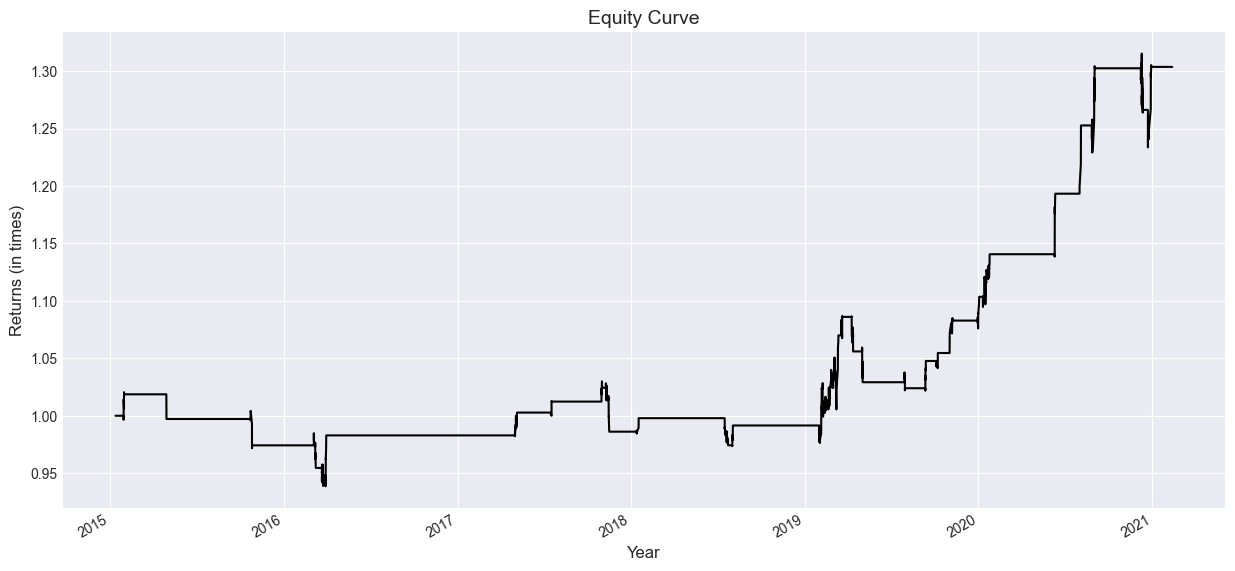

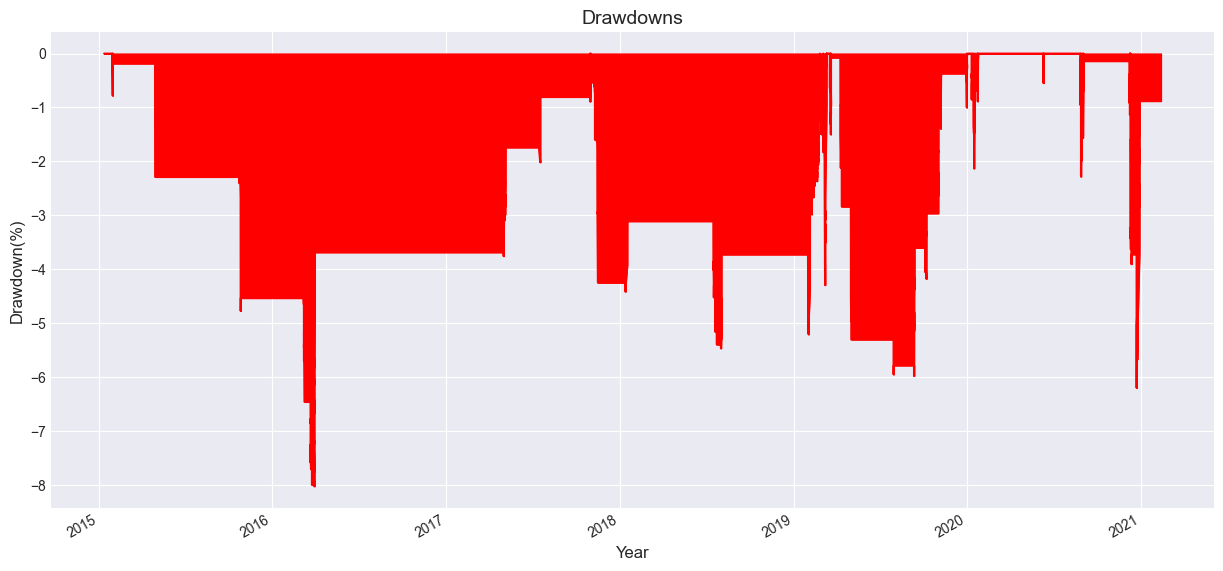

                 Strategy
CAGR                4.51%
Sharpe Ratio         0.52
Maximum Drawdown   -8.03%


In [17]:
# Strategy performance
get_performance_metrics(strategy_data)

Over the backtested period, the strategy generated a CAGR of 4.51% with a Sharpe ratio of 0.52 and a maximum drawdown limited to -8.03%.

<a id='summary'></a>
## Summary and Next Steps

You have successfully created and backtested the trend-based trading strategy based on the weekly Woodie's. Feel free to tweak all of the strategy parameters to customise the strategy as per your preference. 

In the upcoming units, we will build another trend-based strategy which will be based on the Camarilla pivots. <br><br>